Matplotlib is building the font cache; this may take a moment.


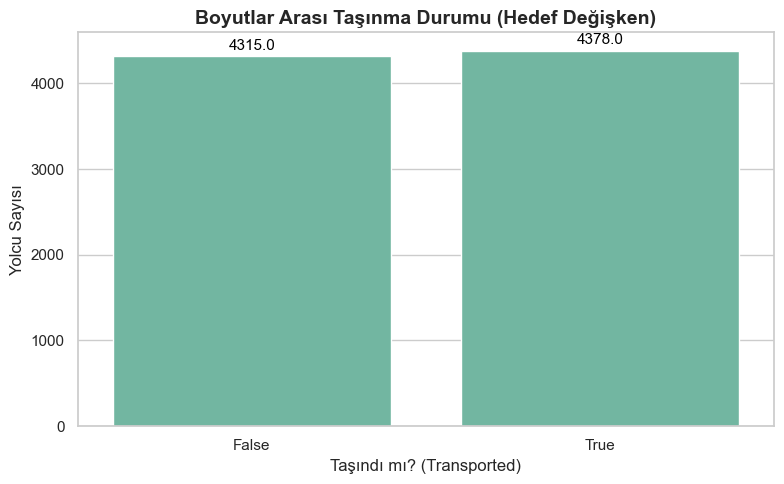

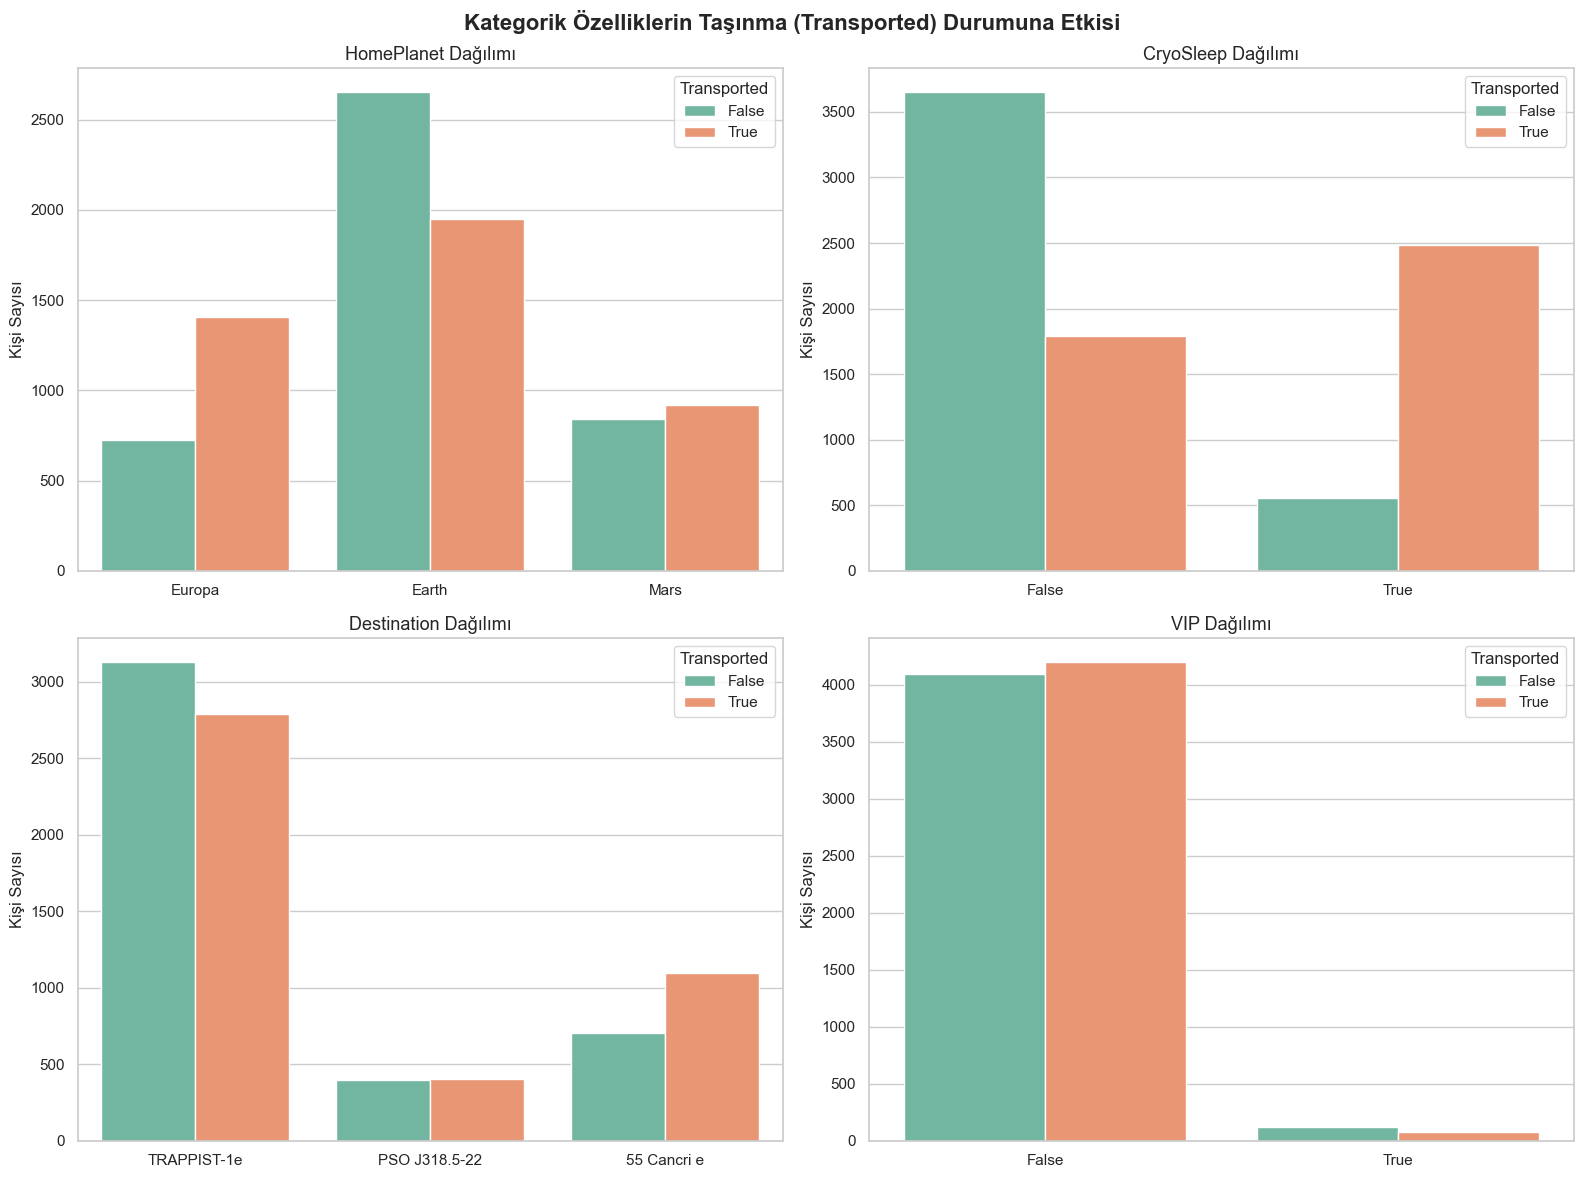

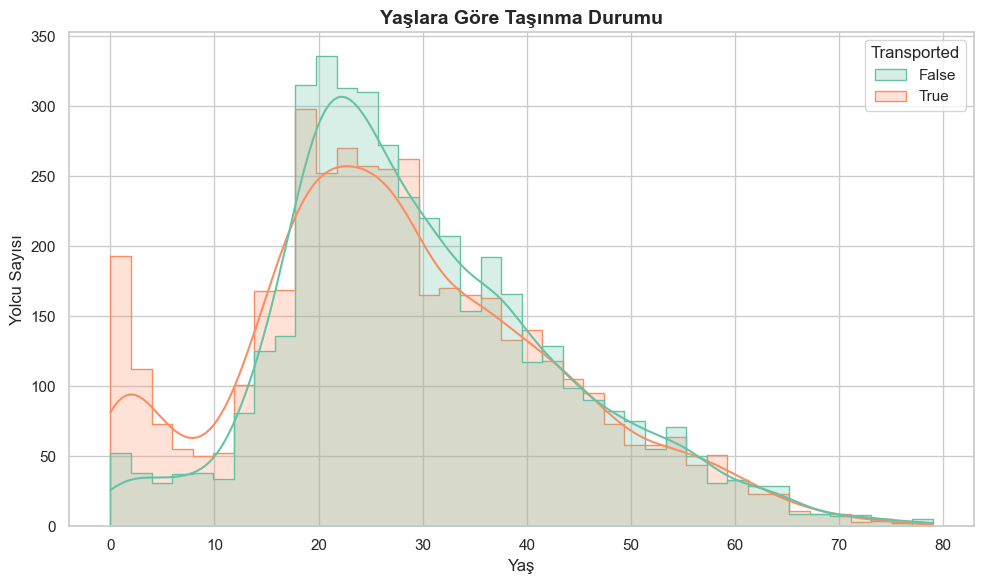

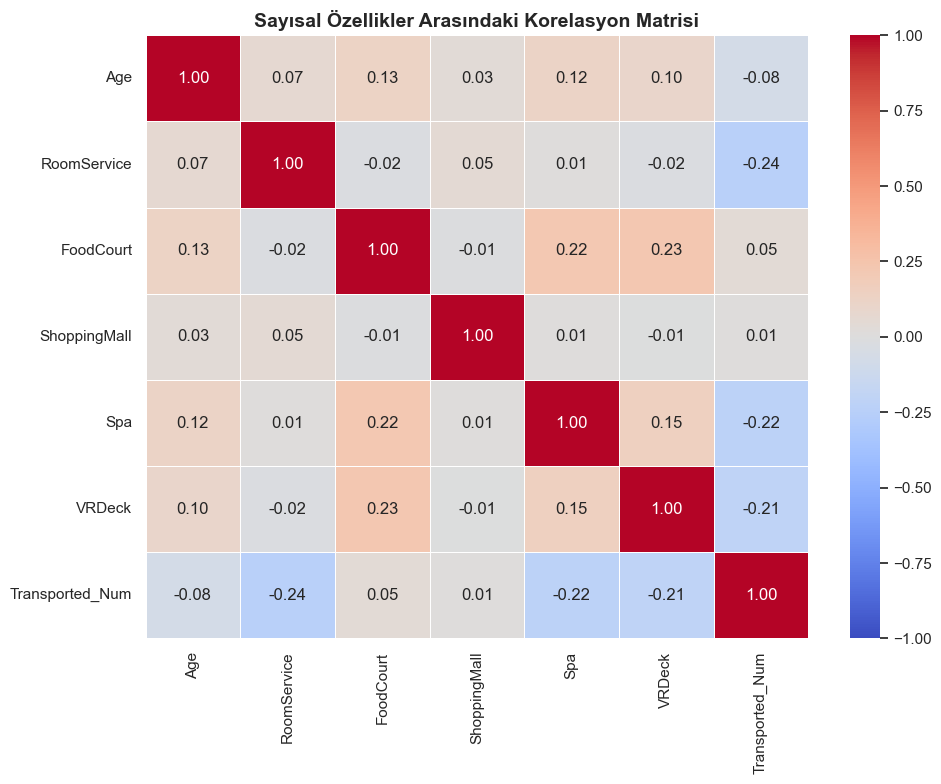

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Temayı ayarlayalım (Sunumlarda şık durması için)
sns.set_theme(style="whitegrid", palette="Set2")

# Veriyi yükleme
train_df = pd.read_csv("train.csv")

# 1. Hedef Değişken (Transported) Dağılımı
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='Transported')
plt.title('Boyutlar Arası Taşınma Durumu (Hedef Değişken)', fontsize=14, fontweight='bold')
plt.xlabel('Taşındı mı? (Transported)', fontsize=12)
plt.ylabel('Yolcu Sayısı', fontsize=12)
# Barların üzerine sayıları ekleme
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()

# 2. Kategorik Değişkenlerin Hedef ile İlişkisi (Çoklu Grafik)
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Kategorik Özelliklerin Taşınma (Transported) Durumuna Etkisi', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_features):
    ax = axes[i//2, i%2]
    sns.countplot(data=train_df, x=col, hue='Transported', ax=ax)
    ax.set_title(f'{col} Dağılımı', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Kişi Sayısı')

plt.tight_layout()
plt.show()

# 3. Yaş (Age) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Transported', bins=40, kde=True, element="step")
plt.title('Yaşlara Göre Taşınma Durumu', fontsize=14, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Yolcu Sayısı', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Sayısal Değişkenler Arası Korelasyon Matrisi
# Transported sütununu korelasyon için numerik (0-1) yapalım
train_df['Transported_Num'] = train_df['Transported'].astype(int)

# Sadece sayısal sütunları seçme
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported_Num']
corr = train_df[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Sayısal Özellikler Arasındaki Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

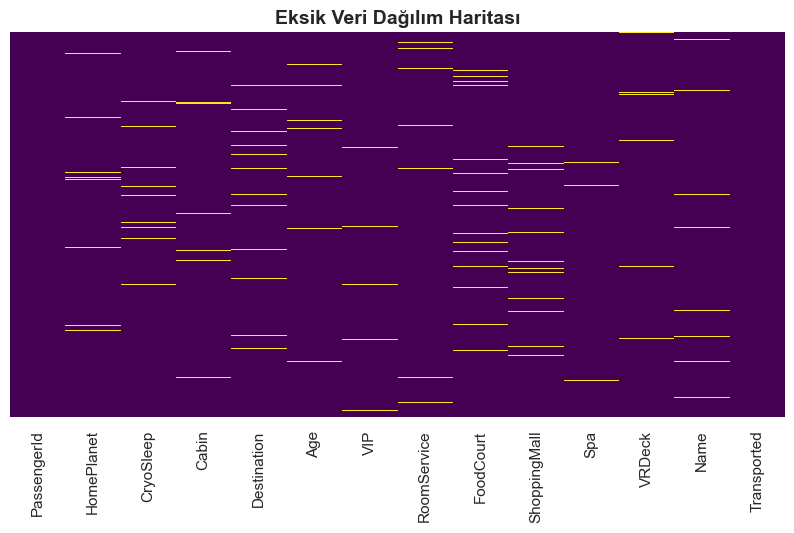

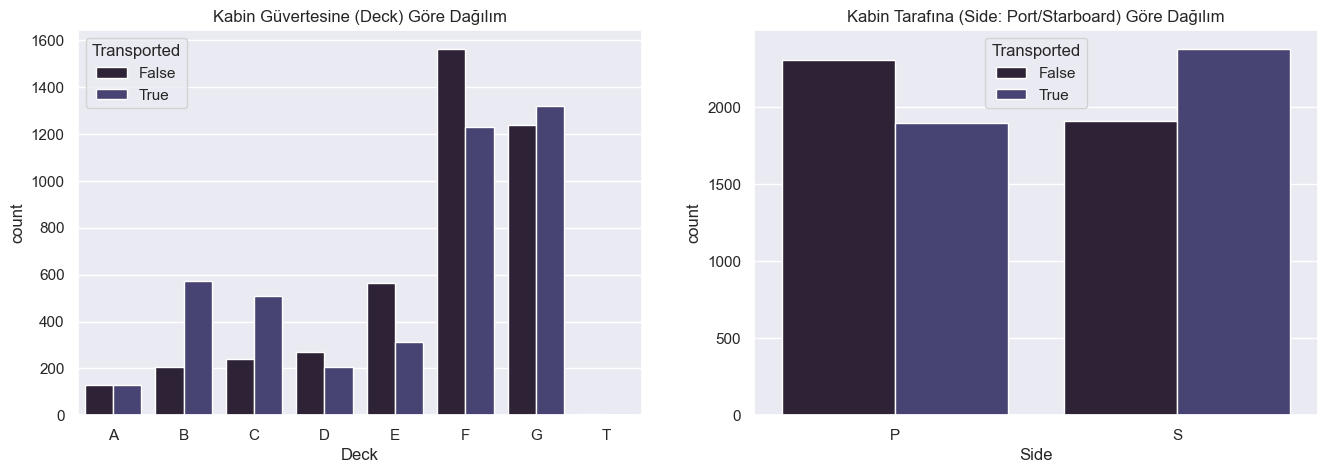

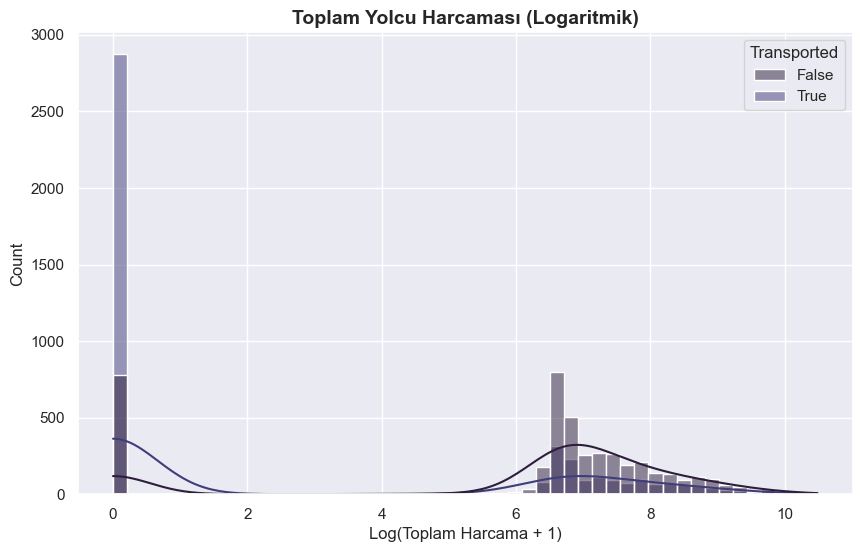

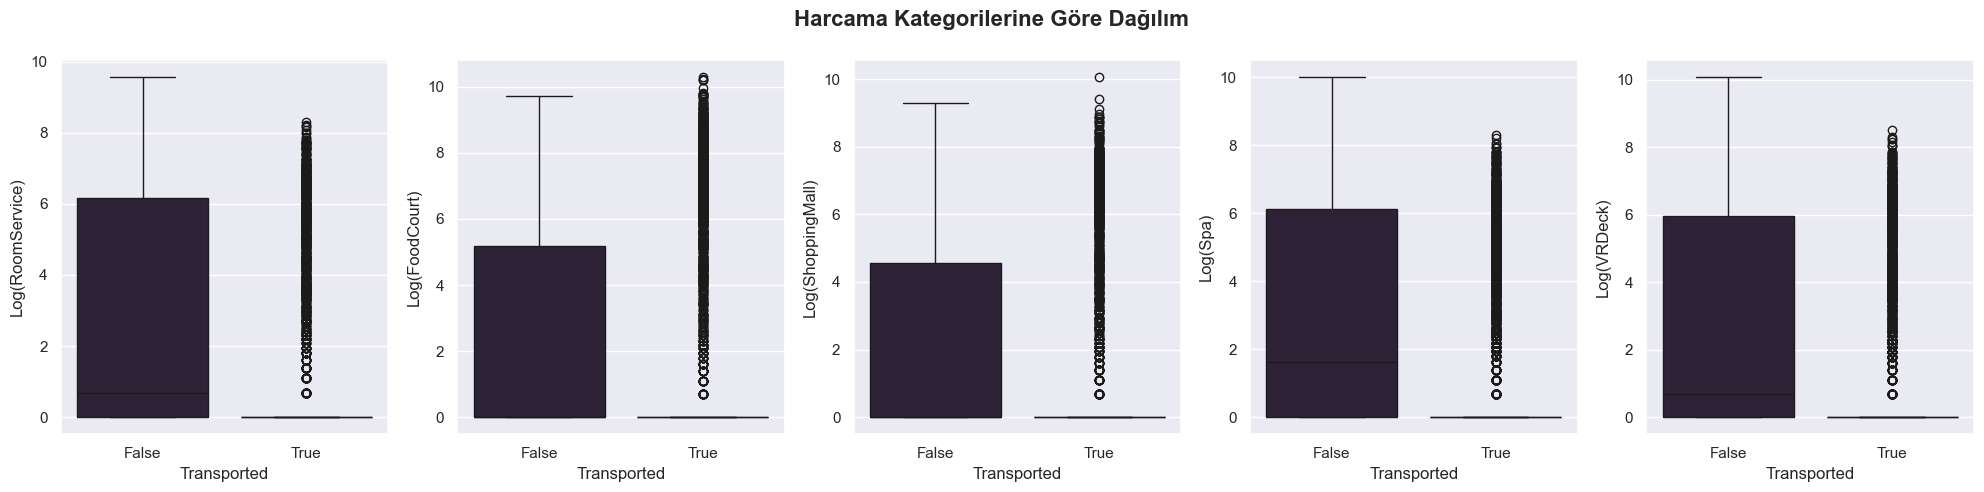

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Temayı ayarlayalım
sns.set_theme(style="darkgrid", palette="mako")

train_df = pd.read_csv("train.csv")

# 1. Eksik Veriler
plt.figure(figsize=(10, 5))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Eksik Veri Dağılım Haritası', fontsize=14, fontweight='bold')
plt.show()

# 2 & 3. Kabin (Cabin) Özelliğini Parçalama
train_df[['Deck', 'Num', 'Side']] = train_df['Cabin'].str.split('/', expand=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
deck_order = train_df['Deck'].dropna().sort_values().unique()

sns.countplot(data=train_df, x='Deck', hue='Transported', order=deck_order, ax=axes[0])
axes[0].set_title('Kabin Güvertesine (Deck) Göre Dağılım')

sns.countplot(data=train_df, x='Side', hue='Transported', ax=axes[1])
axes[1].set_title('Kabin Tarafına (Side: Port/Starboard) Göre Dağılım')
plt.show()

# 4. Toplam Harcama Davranışı
luxury_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df['TotalExpenditure'] = train_df[luxury_cols].sum(axis=1)

plt.figure(figsize=(10, 6))
# Sıfır değerleri bozmasın diye log1p (log(x+1)) kullanıyoruz
sns.histplot(x=np.log1p(train_df['TotalExpenditure']), hue=train_df['Transported'], bins=50, kde=True)
plt.title('Toplam Yolcu Harcaması (Logaritmik)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Toplam Harcama + 1)')
plt.show()

# 5. Harcama Kalemleri Aykırı Değer (Outlier) Analizi
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(luxury_cols):
    sns.boxplot(y=np.log1p(train_df[col]), x=train_df['Transported'], ax=axes[i])
    axes[i].set_ylabel(f'Log({col})')
plt.suptitle('Harcama Kategorilerine Göre Dağılım', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

2.

In [4]:
import pandas as pd
import numpy as np

# Veriyi yükleme
df = pd.read_csv("train.csv")

# 1. İsmi Parçalama (Name & Surname) ve Grup Numarasını Çıkarma
df[['FirstName', 'Surname']] = df['Name'].str.split(' ', expand=True)
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])

# 2. Harcamaları Birleştirme (Total_Expense)
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['Total_Expense'] = df[expense_cols].sum(axis=1)

# ==========================================
# EKSİK VERİ DOLDURMA (IMPUTATION) İŞLEMLERİ
# ==========================================

# 3. HomePlanet (Ana Gezegen) Doldurma
# - Önce "Aynı gruptakiler (Group) aynı gezegenden gelmiştir" kuralı
group_planet = df.dropna(subset=['HomePlanet']).groupby('Group')['HomePlanet'].first().to_dict()
df['HomePlanet'] = df['HomePlanet'].fillna(df['Group'].map(group_planet))
# - Hala boşluk varsa "Aynı aileden (Surname) olanlar aynı gezegenden gelmiştir" kuralı
surname_planet = df.dropna(subset=['HomePlanet']).groupby('Surname')['HomePlanet'].first().to_dict()
df['HomePlanet'] = df['HomePlanet'].fillna(df['Surname'].map(surname_planet))

# 4. CryoSleep (Kriyojenik Uyku) Doldurma
# - Kural 1: Eğer yolcu harcama yaptıysa uyumuyordur (False).
df.loc[(df['CryoSleep'].isnull()) & (df['Total_Expense'] > 0), 'CryoSleep'] = False
# - Kural 2: Aynı odada (Cabin) kalanlar aynı CryoSleep durumuna sahip olabilir.
cabin_cryo_nunique = df.dropna(subset=['CryoSleep']).groupby('Cabin')['CryoSleep'].nunique()
pure_cabins = cabin_cryo_nunique[cabin_cryo_nunique == 1].index # Odadaki herkes aynı durumda olan odalar
cabin_cryo_map = df[df['Cabin'].isin(pure_cabins)].groupby('Cabin')['CryoSleep'].first().to_dict()
df['CryoSleep'] = df['CryoSleep'].fillna(df['Cabin'].map(cabin_cryo_map))
# - Kural 3 (İnisiyatif): Kalan yaklaşık 70 kişi için; eğer hiç harcama yapmamışlarsa "True" (Uyuyor) kabul edelim, diğerlerini "False" kabul edelim.
df.loc[(df['CryoSleep'].isnull()) & (df['Total_Expense'] == 0), 'CryoSleep'] = True
df['CryoSleep'] = df['CryoSleep'].fillna(False)

# 5. Cabin (Kabin) Doldurma ve Parçalama
# - Kural 1: Soyismi aynı olan aileleri aynı kabine koyalım.
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else np.nan

surname_cabin_map = df.dropna(subset=['Cabin']).groupby('Surname')['Cabin'].agg(get_mode).to_dict()
df['Cabin'] = df['Cabin'].fillna(df['Surname'].map(surname_cabin_map))

# 6. Destination (Gidilecek Yer) Doldurma
# - Kural 1: Aynı ailedense (Surname) aynı yere gidiyordur.
surname_dest_map = df.dropna(subset=['Destination']).groupby('Surname')['Destination'].agg(get_mode).to_dict()
df['Destination'] = df['Destination'].fillna(df['Surname'].map(surname_dest_map))

# 7. Age (Yaş) Doldurma
# - Geldikleri gezegene (HomePlanet) göre yaş medyanını alalım (Medyan aykırı değerlerden etkilenmediği için mantıklıdır).
df['Age'] = df.groupby('HomePlanet')['Age'].transform(lambda x: x.fillna(x.median()))
# (Eğer gezegeni hala belli olmayan varsa, genel medyan ile doldur)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 8. VIP Doldurma
# - Kural: Aynı kabinde (Cabin) kalan biri VIP ise, boş olanı da VIP olarak işaretle. Değilse False.
cabin_vip_map = df.dropna(subset=['VIP']).groupby('Cabin')['VIP'].agg(lambda x: any(x)).to_dict()
df['VIP'] = df['VIP'].fillna(df['Cabin'].map(cabin_vip_map))
df['VIP'] = df['VIP'].fillna(False) # Kalan tüm VIP'ler azınlık olduğu için False kabul edildi.

# 9. AZ KALAN BOŞLUKLARI SİLME İŞLEMİ
# HomePlanet (12 kişi), Cabin (11 kişi) ve Destination (12 kişi) kısımlarında
# inisiyatif yerine "az ise sil" kuralınızı uyguluyoruz.
df = df.dropna(subset=['HomePlanet', 'Cabin', 'Destination'])

# Silinmeden sonra kabini son olarak parçalayalım
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

# Son Kontrol
print(df.isnull().sum())

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin              0
Destination        0
Age                0
VIP                0
RoomService      181
FoodCourt        181
ShoppingMall     206
Spa              182
VRDeck           188
Name             190
Transported        0
FirstName        190
Surname          190
Group              0
Total_Expense      0
Deck               0
Num                0
Side               0
dtype: int64


In [5]:
# Harcama sütunlarını bir listeye alalım
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in expense_cols:
    # Kural 1: Uyuyanların harcaması 0'dır
    df.loc[(df['CryoSleep'] == True) & (df[col].isnull()), col] = 0

    # Kural 2: 13 yaşından küçüklerin harcaması 0'dır
    df.loc[(df['Age'] < 13) & (df[col].isnull()), col] = 0

    # Kural 3: Kalan boşlukları VIP durumuna (veya HomePlanet'e) göre medyan alarak doldur
    # Burada sadece 'VIP' değil, ['VIP', 'HomePlanet'] diyerek çok daha hassas bir grup oluşturduk.
    # Yani "Dünyalı bir VIP" ile "Marslı bir VIP"nin harcamasını ayrı ayrı değerlendirmiş oluyoruz.
    df[col] = df.groupby(['VIP', 'HomePlanet'])[col].transform(lambda x: x.fillna(x.median()))

    # Güvenlik Ağı: Eğer o spesifik grupta hiç veri yoksa (örn: o gezegenden hiç VIP yoksa ve NaN döndüyse)
    # Kalan çok nadir boşlukları sadece VIP durumuna göre tekrar doldur
    df[col] = df.groupby('VIP')[col].transform(lambda x: x.fillna(x.median()))

    # Hala boşluk kalırsa (çok düşük ihtimal) genel medyanı ver
    df[col] = df[col].fillna(df[col].median())

# Tüm harcamalar doldurulduktan sonra 'Total_Expense' (Toplam Harcama) sütununu tekrar güncelleyelim
df['Total_Expense'] = df[expense_cols].sum(axis=1)

print("Harcama sütunlarındaki eksik veri kontrolü:")
print(df[expense_cols].isnull().sum())

Harcama sütunlarındaki eksik veri kontrolü:
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


In [6]:
# Artık işimize yaramayacak olan veya yenilerini ürettiğimiz eski sütunların listesi
cols_to_drop = [
    'Name', 'FirstName', 'Surname',  # İsimler ezbere (overfitting) yol açabilir
    'Cabin',                         # Zaten Deck, Num ve Side olarak 3'e böldük
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck' # Bunları Total_Expense yaptık
]

# Sütunları veri setinden siliyoruz (drop)
# errors='ignore' parametresi, eğer o sütun zaten silinmişse hata vermesini engeller
df = df.drop(columns=cols_to_drop, errors='ignore')

# Verinin son halindeki sütunları ve ilk 5 satırı görelim
print("Kalan Sütunlar:", df.columns.tolist())
print(df.head().to_string())

Kalan Sütunlar: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Transported', 'Group', 'Total_Expense', 'Deck', 'Num', 'Side']
  PassengerId HomePlanet CryoSleep  Destination   Age    VIP  Transported Group  Total_Expense Deck Num Side
0     0001_01     Europa     False  TRAPPIST-1e  39.0  False        False  0001            0.0    B   0    P
1     0002_01      Earth     False  TRAPPIST-1e  24.0  False         True  0002          736.0    F   0    S
2     0003_01     Europa     False  TRAPPIST-1e  58.0   True        False  0003        10383.0    A   0    S
3     0003_02     Europa     False  TRAPPIST-1e  33.0  False        False  0003         5176.0    A   0    S
4     0004_01      Earth     False  TRAPPIST-1e  16.0  False         True  0004         1091.0    F   1    S


In [7]:
# --- KODLARIN DEVAMINA EKLEYECEĞİN ENCODING KISMI ---

# 1. İkilik Dönüşüm: True/False olanları 1 ve 0 yapıyoruz
# CryoSleep, VIP ve hedef değişkenimiz olan Transported'ı sayısallaştıralım
bool_cols = ['CryoSleep', 'VIP', 'Transported']
for col in bool_cols:
    df[col] = df[col].astype(int)

# Num (Oda numarası) ve Group verilerini de sayısal formata çekelim
df['Num'] = df['Num'].astype(int)
df['Group'] = df['Group'].astype(int)

# 2. One-Hot Encoding: Çok seçenekli metinleri (Gezegen, Güverte vb.) şalter sistemine çeviriyoruz
# Bu işlem HomePlanet_Europa, Deck_B gibi yeni sütunlar oluşturur
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# PassengerId artık işimize yaramaz (sadece kimlik numarası), onu siliyoruz
df = df.drop(columns=['PassengerId'], errors='ignore')

# SONUÇ: Verinin son halini görelim
print("Veri başarıyla sayısallaştırıldı. Yeni sütun sayısı:", len(df.columns))
print(df.head())

# Artık bu df'i doğrudan makine öğrenmesi modeline sokabilirsin.

Veri başarıyla sayısallaştırıldı. Yeni sütun sayısı: 19
   CryoSleep   Age  VIP  Transported  Group  Total_Expense  Num  \
0          0  39.0    0            0      1            0.0    0   
1          0  24.0    0            1      2          736.0    0   
2          0  58.0    1            0      3        10383.0    0   
3          0  33.0    0            0      3         5176.0    0   
4          0  16.0    0            1      4         1091.0    1   

   HomePlanet_Europa  HomePlanet_Mars  Destination_PSO J318.5-22  \
0                  1                0                          0   
1                  0                0                          0   
2                  1                0                          0   
3                  1                0                          0   
4                  0                0                          0   

   Destination_TRAPPIST-1e  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  \
0                        1       1       0       0    

In [8]:
# Veri setinin son halini CSV olarak kaydetme
df.to_csv("final_train_data.csv", index=False)

print("Tebrikler! Veri seti 'final_train_data.csv' adıyla kaydedildi.")

Tebrikler! Veri seti 'final_train_data.csv' adıyla kaydedildi.
